# Bandit results


Using: C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\tables\experiment_results_full_online_none.parquet


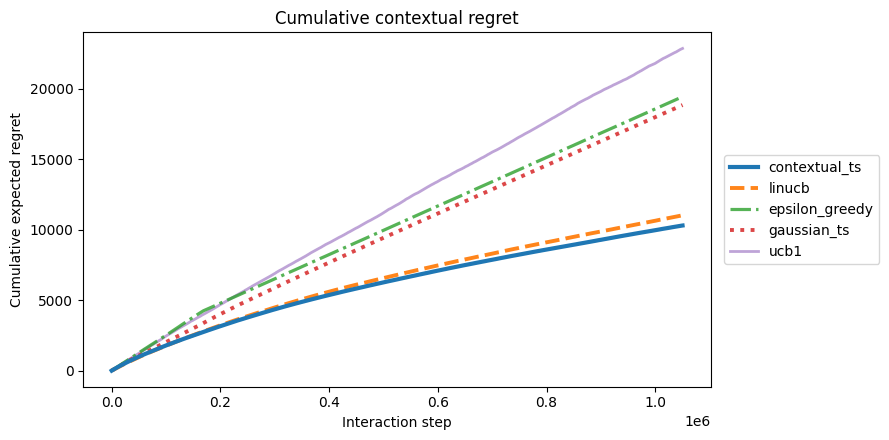

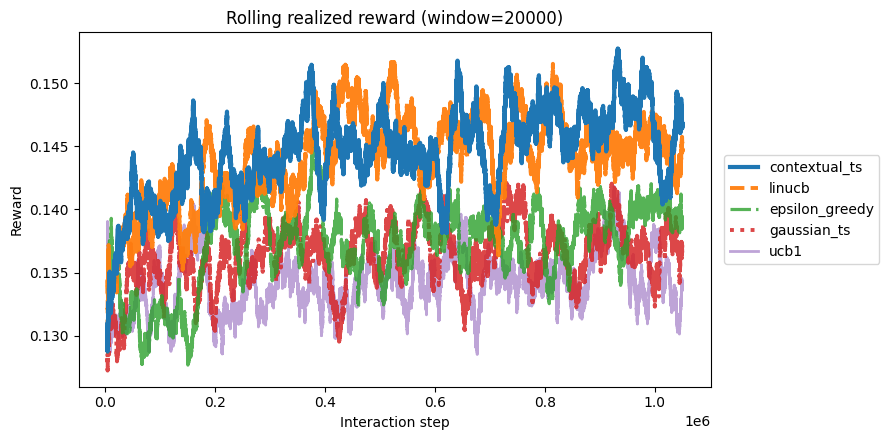

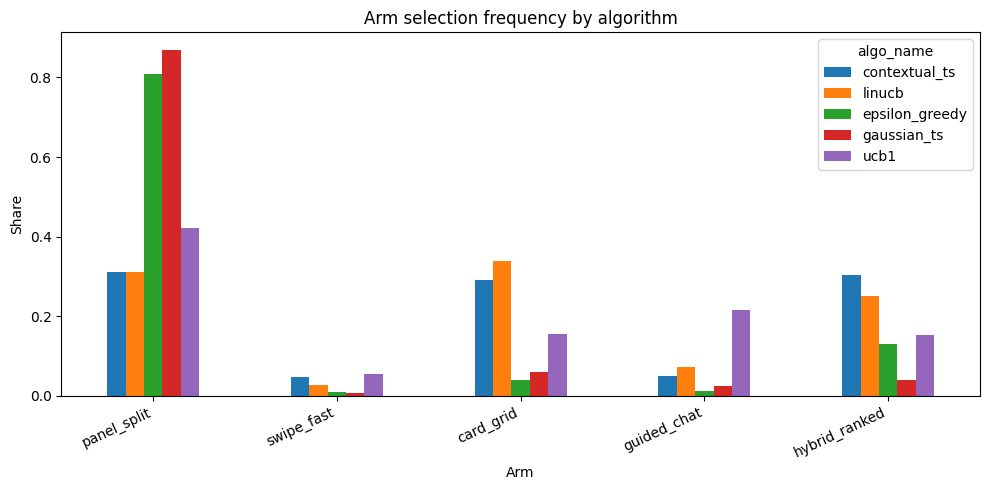

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == "notebooks" else cwd

fig_dir = root / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

candidates = [
    root / "outputs" / "tables" / "experiment_results_full_online_none.parquet",
    root / "outputs" / "tables" / "experiment_results_medium_online_none.parquet",
    root / "outputs" / "tables" / "experiment_results_debug_online_none.parquet",
]

res_path = next((p for p in candidates if p.exists()), None)
if res_path is None:
    raise FileNotFoundError("No experiment_results parquet found in outputs/tables")

print("Using:", res_path)

res = pd.read_parquet(res_path).copy()
res["step_index"] = res.groupby(["seed", "algo_name"]).cumcount()

avg = (
    res.groupby(["algo_name", "step_index"], as_index=False)
       .agg(
           cumulative_reward=("cumulative_reward", "mean"),
           cumulative_expected_regret=("cumulative_expected_regret", "mean"),
           reward_realized=("reward_realized", "mean"),
       )
)

algo_order = ["contextual_ts", "linucb", "epsilon_greedy", "gaussian_ts", "ucb1"]
algo_order = [a for a in algo_order if a in res["algo_name"].unique()]

styles = {
    "contextual_ts": dict(linestyle="-",  linewidth=3.0, alpha=1.00, zorder=5),
    "linucb":        dict(linestyle="--", linewidth=2.8, alpha=0.95, zorder=4),
    "epsilon_greedy":dict(linestyle="-.", linewidth=2.3, alpha=0.80, zorder=3),
    "gaussian_ts":   dict(linestyle=":",  linewidth=2.8, alpha=0.85, zorder=2),
    "ucb1":          dict(linestyle="-",  linewidth=2.0, alpha=0.60, zorder=1),
}

# cumulative regret
plt.figure(figsize=(9, 4.5))
for name in algo_order:
    d = avg[avg["algo_name"] == name].sort_values("step_index")
    plt.plot(
        d["step_index"],
        d["cumulative_expected_regret"],
        label=name,
        **styles.get(name, {})
    )
plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
plt.title("Cumulative contextual regret")
plt.xlabel("Interaction step")
plt.ylabel("Cumulative expected regret")
plt.tight_layout()
plt.savefig(fig_dir / "cumulative_contextual_regret.png", dpi=220)
plt.show()

# rolling reward
if "debug" in res_path.name:
    window = 200
elif "medium" in res_path.name:
    window = 1000
else:
    window = 20000
plt.figure(figsize=(9, 4.5))
for name in algo_order:
    d = avg[avg["algo_name"] == name].sort_values("step_index").copy()
    d["rolling_reward"] = d["reward_realized"].rolling(
        window, min_periods=max(10, window // 5)
    ).mean()
    plt.plot(
        d["step_index"],
        d["rolling_reward"],
        label=name,
        **styles.get(name, {})
    )
plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
plt.title(f"Rolling realized reward (window={window})")
plt.xlabel("Interaction step")
plt.ylabel("Reward")
plt.tight_layout()
plt.savefig(fig_dir / "rolling_avg_reward.png", dpi=220)
plt.show()

# arm frequency
freq = (
    res.groupby(["algo_name", "arm_selected_name"])
       .size()
       .rename("count")
       .reset_index()
)
freq["share"] = freq.groupby("algo_name")["count"].transform(lambda x: x / x.sum())

pivot = freq.pivot(index="arm_selected_name", columns="algo_name", values="share").fillna(0)
pivot = pivot.reindex(["panel_split", "swipe_fast", "card_grid", "guided_chat", "hybrid_ranked"])
pivot = pivot.reindex(columns=algo_order)

ax = pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Arm selection frequency by algorithm")
ax.set_xlabel("Arm")
ax.set_ylabel("Share")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "arm_selection_frequency.png", dpi=220)
plt.show()